# 🪶 Shakespeare from Scratch (with `ezpz`)

[Sam Foreman](https://samforeman.me)
(\[[ALCF](https://alcf.anl.gov/about/people/sam-foreman)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
2026-07-24

> **Authors**
>
> Written by [Sam Foreman](https://samforeman.me) for the [Intro to HPC
> Bootcamp](https://intro-hpc-bootcamp.alcf.anl.gov/).

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/02-llms/3-shakespeare-ezpz/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/content/02-llms/3-shakespeare-ezpz/index.qmd)

The [Shakespeare example](../2-shakespeare-example-colab/index.ipynb)
trains a small GPT with the
[`wordplay`](https://github.com/saforem2/wordplay) package. Here we do
the **same thing from scratch** — the model, the data pipeline, the
training loop, and the text generation are all written inline — using
only [`ezpz`](https://github.com/saforem2/ezpz) +
[PyTorch](https://pytorch.org).

> **🎯 What you’ll learn**
>
> - How [`ezpz`](https://github.com/saforem2/ezpz) turns a plain PyTorch
>   loop into a **distributed, instrumented** training run with almost
>   no boilerplate.
> - The pieces of a GPT training program: **config → model → data → loop
>   → metrics → generation**.
> - How to track metrics (`loss`, `dt`, `sps`, `mtps`, `mfu`) with
>   `ezpz.History` and launch at scale with `ezpz launch`.
>
> This page assumes you’ve seen the attention/transformer mechanics from
> [**\[02.0\] Intro to LLMs**](../0-intro-to-llms/index.qmd) — here we
> focus on the *training* side.

## 🎯 Setup

On any ALCF / NERSC system (or a laptop), install `ezpz` and set up the
environment with the one-liner:

``` bash
source <(curl -fsSL https://bit.ly/ezpz-utils) && ezpz_setup .venv
uv pip install "git+https://github.com/saforem2/ezpz"
```

The single most useful thing `ezpz` does is collapse all of PyTorch’s
distributed boilerplate into **one call**. On a real (multi-GPU) run
your script starts like this:

In [1]:
import ezpz

rank = ezpz.setup_torch(seed=1234)   # discovers rank/world/device/backend, inits process group
device = ezpz.get_torch_device()     # 'cuda' | 'xpu' | 'mps' | 'cpu'
logger = ezpz.get_logger(__name__)
logger.info(f"rank {rank} / {ezpz.get_world_size()} on {device}")

> **🔍 …versus raw PyTorch**
>
> That one `setup_torch()` replaces the usual dance:
>
> ``` python
> import os, torch.distributed as dist
> dist.init_process_group(backend="nccl")
> rank        = int(os.environ["RANK"])
> local_rank  = int(os.environ["LOCAL_RANK"])
> world_size  = int(os.environ["WORLD_SIZE"])
> torch.cuda.set_device(local_rank)
> # ...and you still have to detect cuda vs xpu vs cpu yourself
> ```

For this page we build a **tiny** version that actually runs here on
CPU, so we import the plumbing and pick a device directly (on a cluster
you’d use `ezpz.setup_torch()` above instead):

In [2]:
import os
os.environ["WANDB_DISABLED"] = "1"   # keep the tutorial offline
os.environ["WANDB_MODE"] = "disabled"

import math
import time
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
import ezpz

torch.manual_seed(1234)
device = ezpz.get_torch_device()      # 'cpu' here; 'cuda'/'xpu' on a GPU node
logger = ezpz.get_logger(__name__)
logger.info(f"Using device: {device}")

## 📖 The Data: tiny-Shakespeare

We train a **character-level** model: the vocabulary is just the set of
unique characters in the text, and the model predicts the next
character.

In [3]:
import urllib.request
from pathlib import Path

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
path = Path("input.txt")
if not path.exists():
    try:
        urllib.request.urlretrieve(url, path)
    except Exception:
        # offline fallback so this page always renders
        path.write_text(("To be, or not to be, that is the question:\n"
                         "Whether 'tis nobler in the mind to suffer\n"
                         "The slings and arrows of outrageous fortune,\n") * 200)

text = path.read_text()
chars = sorted(set(text))
vocab_size = len(chars)
logger.info(f"{len(text):,} characters, vocab size = {vocab_size}")

Build the char↔int mappings and encode the whole corpus, then split
90/10:

In [4]:
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]              # str -> list[int]
decode = lambda ids: "".join(itos[i] for i in ids)   # list[int] -> str

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

def get_batch(split, batch_size, block_size):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i : i + block_size] for i in ix])
    y = torch.stack([d[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

## 🧱 The Model: a small GPT

A compact decoder-only Transformer — the same architecture as the
`wordplay` model, written inline. (For the *why* behind attention, see
[Intro to LLMs](../0-intro-to-llms/index.qmd).)

In [5]:
from dataclasses import dataclass

@dataclass
class GPTConfig:
    vocab_size: int
    block_size: int = 256
    n_layer: int = 6
    n_head: int = 6
    n_embd: int = 384
    dropout: float = 0.2


class Block(nn.Module):
    """A single Transformer block: masked self-attention + MLP."""
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.n_embd)
        self.attn = nn.MultiheadAttention(
            cfg.n_embd, cfg.n_head, dropout=cfg.dropout, batch_first=True
        )
        self.ln2 = nn.LayerNorm(cfg.n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(cfg.n_embd, 4 * cfg.n_embd),
            nn.GELU(),
            nn.Linear(4 * cfg.n_embd, cfg.n_embd),
            nn.Dropout(cfg.dropout),
        )
        self.register_buffer(
            "mask", torch.triu(torch.ones(cfg.block_size, cfg.block_size), 1).bool()
        )

    def forward(self, x):
        T = x.size(1)
        h = self.ln1(x)
        a, _ = self.attn(h, h, h, attn_mask=self.mask[:T, :T], need_weights=False)
        x = x + a
        x = x + self.mlp(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.n_embd)
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.n_embd)
        self.head = nn.Linear(cfg.n_embd, cfg.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        logits = self.head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B * T, -1), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.cfg.block_size :]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
        return idx

## ⚡ Going distributed with `ezpz`

On multiple GPUs, wrapping the model for **Distributed Data Parallel**
is where `ezpz` shines — but the beauty is that the *training loop below
doesn’t change*. On a cluster you’d add:

In [6]:
# after `model = GPT(cfg).to(device)` on a real multi-GPU run:
from torch.nn.parallel import DistributedDataParallel as DDP

if ezpz.get_world_size() > 1:
    model = DDP(model, device_ids=[ezpz.get_local_rank()])

`ezpz` handles the process-group setup (from `setup_torch()`), device
placement, and the correct backend (NCCL / oneCCL / gloo) for you — so
the *same script* runs on 1 GPU, 8 GPUs, or 100 nodes.

## 🔁 The Training Loop + Metrics

Here’s the heart of it. We use a **tiny config so this page runs on
CPU** in a few seconds, and lean on `ezpz` for three things:

- `ezpz.synchronize()` — backend-agnostic device sync for **correct
  timing**,
- `ezpz.History` — accumulates per-step metrics and prints a compact
  summary,
- (later) `history.finalize()` — writes plots + a report automatically.

We report the same metrics as the `wordplay` example:

|  name  | description                 |
|:------:|:----------------------------|
| `step` | training iteration          |
| `loss` | cross-entropy loss          |
|  `dt`  | time per step (s)           |
| `sps`  | samples per second          |
| `mtps` | (million) tokens per second |
| `mfu`  | model FLOPs utilization (%) |

Table 1: Training metrics legend

In [7]:
# The config scales with the hardware: a real GPT on a GPU, a tiny fast one on a
# CPU build. On a GPU node (this page was rendered on a Polaris A100) you get a
# genuine ~1000-step run that produces Shakespeare-like text; a laptop build runs
# a small version so the page still renders quickly.
on_gpu = device in ("cuda", "xpu")

if on_gpu:
    cfg = GPTConfig(vocab_size=vocab_size, block_size=256, n_layer=6, n_head=6,
                    n_embd=384, dropout=0.2)
    batch_size = 64
    max_iters = 1000
    PEAK_FLOPS = 3.12e14      # A100 bf16 peak (~312 TFLOP/s)
else:
    cfg = GPTConfig(vocab_size=vocab_size, block_size=64, n_layer=4, n_head=4,
                    n_embd=128, dropout=0.0)
    batch_size = 16
    max_iters = 50
    PEAK_FLOPS = 1.0e12       # ~1 TFLOP/s nominal (CPU)

model = GPT(cfg).to(device)
n_params = sum(p.numel() for p in model.parameters())
logger.info(f"model has {n_params/1e6:.2f}M parameters ({max_iters} steps on {device})")

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# Rough MFU: ~6*N FLOPs per token (fwd+bwd), against the device's peak above.
flops_per_token = 6 * n_params

In [8]:
history = ezpz.History()

model.train()
for step in range(max_iters):
    x, y = get_batch("train", batch_size, cfg.block_size)

    ezpz.synchronize(device)
    t0 = time.perf_counter()

    _, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    ezpz.synchronize(device)
    dt = time.perf_counter() - t0

    tokens = batch_size * cfg.block_size
    metrics = {
        "step": step,
        "loss": loss.item(),
        "dt": dt,
        "sps": batch_size / dt,
        "mtps": tokens / dt / 1e6,
        "mfu": 100 * flops_per_token * tokens / dt / PEAK_FLOPS,
    }
    summary = history.update(metrics)
    if step % 10 == 0:
        logger.info(summary)

## 💬 Generating Text

The `generate()` method samples one character at a time. Let’s compare
**before** and **after** training — a few dozen CPU steps won’t produce
Shakespeare, but the shift from pure noise toward text-like structure is
already visible (train for 1000+ steps on a GPU for the real thing):

In [9]:
prompt = "\n"
ctx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
sample = decode(model.generate(ctx, max_new_tokens=200, temperature=0.8, top_k=16)[0].tolist())
logger.info("--- sample after tiny training run ---\n" + sample)

## 📊 Plots & Report, for free

`ezpz.History` can turn the metrics you logged into plots and a report
with a single call — it writes loss curves (matplotlib **and** terminal
plots), an `xarray` dataset, and a `report.md`:

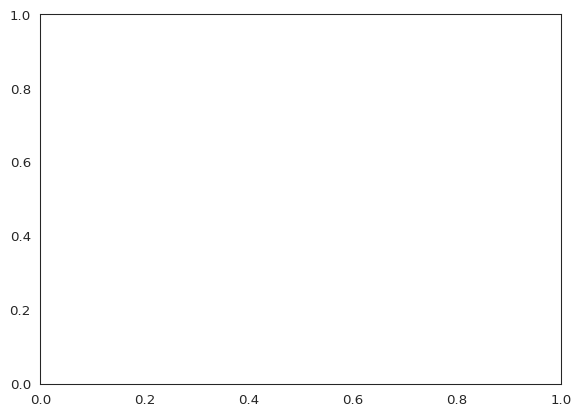

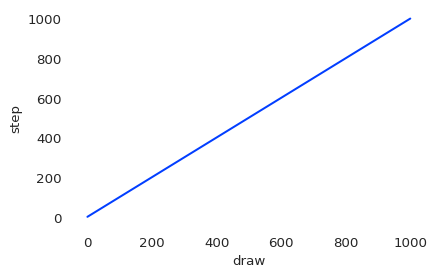

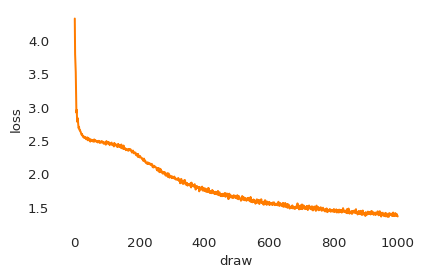

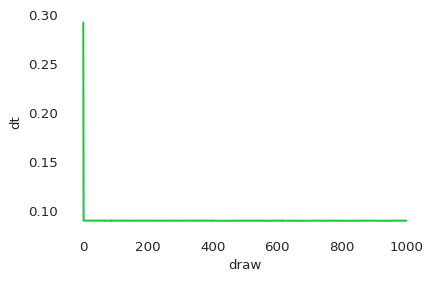

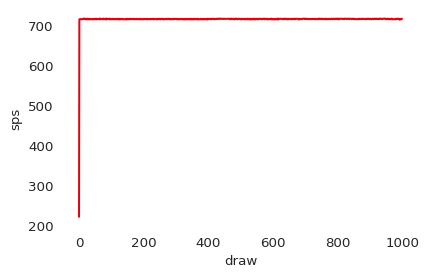

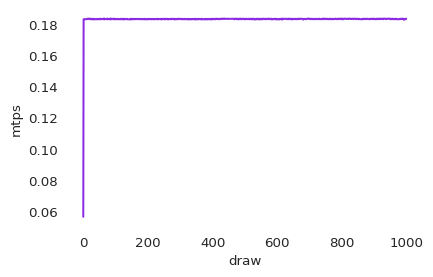

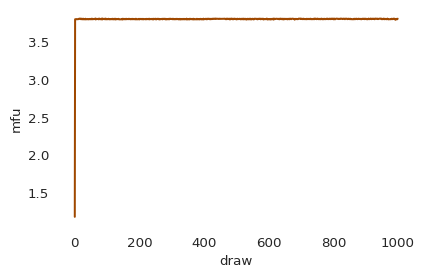

In [10]:
import io
import contextlib
from pathlib import Path

outdir = Path("outputs")
# finalize() writes plots/report to disk but also prints terminal-plot noise and
# leaves an empty matplotlib figure open; hush stdout and drop the stray figure.
import matplotlib.pyplot as plt
with contextlib.redirect_stdout(io.StringIO()):
    _ = history.finalize(outdir=outdir)
plt.close("all")

logger.info("wrote: " + ", ".join(sorted(p.name for p in outdir.iterdir())))

`finalize()` also saves each metric as a PNG, a `report.md`, and an
`xarray` dataset. The per-step numbers live in `history.data` (a dict of
lists), so we can plot the four headline metrics ourselves — **loss**
(is it learning?), **mfu** (how well are we using the hardware?), and
**sps** / **mtps** (throughput):

In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from bootcamp.plotly_theme import apply_theme, COLORS
apply_theme()

d = history.data                       # {"step": [...], "loss": [...], ...}
panels = [("loss", "loss", "blue"), ("mfu", "MFU (%)", "green"),
          ("sps", "samples/sec", "orange"), ("mtps", "M tokens/sec", "purple")]
fig = make_subplots(rows=2, cols=2, subplot_titles=[p[1] for p in panels])
for i, (key, _lab, color) in enumerate(panels):
    r, c = divmod(i, 2)
    fig.add_scatter(x=d["step"], y=d[key], mode="lines", line=dict(color=COLORS[color]),
                    name=key, showlegend=False, row=r + 1, col=c + 1)
fig.update_layout(height=460, margin=dict(t=40))
fig.update_xaxes(title_text="step", row=2, col=1)
fig.update_xaxes(title_text="step", row=2, col=2)
fig.show()

> **🔬 On a real run**
>
> Point `ezpz.History(backends="wandb")` at [Weights &
> Biases](https://wandb.ai) (or `"mlflow"`) and every metric streams to
> your dashboard live — no code changes beyond that one argument.

## 🚀 Scaling Up

To train the **full ~10M-parameter model** (like the `wordplay` example)
across multiple GPUs, drop the loop above into a `train.py` that starts
with `ezpz.setup_torch()` + DDP, bump the config to the real size, and
launch with `ezpz launch` — which auto-detects PBS (`mpiexec`) / SLURM
(`srun`):

``` bash
# full config: block_size=256, n_layer=6, n_head=6, n_embd=384, max_iters=1000
ezpz launch python3 train.py
```

That’s the whole point: **the training code you wrote above doesn’t
change** — `ezpz` handles going from your laptop’s CPU to a rack of
GPUs.

## 🎒 Homework

1.  **Train it for real.** Bump `max_iters` to 1000+ and the config to
    the full size (`block_size=256, n_embd=384, n_layer=6`), run on a
    GPU node, and paste a generated sample. Does it start sounding like
    Shakespeare?
2.  **Compare to `wordplay`.** Run the [wordplay
    version](../2-shakespeare-example-colab/index.ipynb) with the same
    config. Do the loss curves and samples match? What does `wordplay`
    add on top of what you wrote here?
3.  **Scale out.** Launch across 2+ GPUs with `ezpz launch`, add the DDP
    wrap, and report the `sps`/`mtps` speedup vs. a single GPU.

## 📚 References

- [`saforem2/ezpz`](https://github.com/saforem2/ezpz) ·
  [ezpz.cool](https://ezpz.cool)
- [`saforem2/wordplay`](https://github.com/saforem2/wordplay) — the
  packaged version of this example
- [Andrej Karpathy, “Let’s build GPT”
  (nanoGPT)](https://www.youtube.com/watch?v=kCc8FmEb1nY)
- [Vaswani et al., *Attention Is All You
  Need*](https://arxiv.org/abs/1706.03762)